# Results Analysis

This notebook loads every cached trial JSON from `results/` and analyses them without re-running any GA.

**What is covered:**
1. Load all runs into a single flat DataFrame
2. Overall best run across all experiments
3. Parameter-level analysis (population size, generations, elitism, crossover, mutation rate, selection type)
4. Diversity method comparison (fitness sharing σ, restricted mating strategies)
5. Grid search & random search results
6. Final summary — best configuration per experiment group

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

warnings.filterwarnings("ignore")

results_root = project_root / "results"

print(f"Project root : {project_root}")
print(f"Results root : {results_root}")

Project root : /Users/mehmet/src/CIFO_project
Results root : /Users/mehmet/src/CIFO_project/results


In [2]:
def param_summary(data: pd.DataFrame, group_col: str, label: str = None) -> pd.DataFrame:
    """Aggregate RMSE statistics grouped by one parameter column."""
    label = label or group_col
    agg = (
        data.groupby(group_col)["best_fitness"]
        .agg(n="count", mean="mean", std="std", min="min", max="max")
        .reset_index()
        .rename(columns={group_col: label})
        .sort_values("mean")
    )
    agg["std"] = agg["std"].fillna(0)
    return agg


def bar_with_error(ax, labels, means, stds, title, ylabel="Mean RMSE", color="steelblue"):
    """Horizontal bar chart with error bars, annotated with mean ± std."""
    y = range(len(labels))
    ax.barh(y, means, xerr=stds, color=color, alpha=0.8,
            error_kw=dict(ecolor="black", capsize=4, lw=1.2), height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel(ylabel)
    ax.set_title(title, fontweight="bold")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(m + s + 0.0005, i, f"{m:.5f}", va="center", fontsize=8.5)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.4)


def show_table(data: pd.DataFrame, fmt: dict | None = None, highlight_min: str | None = None) -> None:
    """Display a DataFrame with optional per-column printf formatting. No jinja2 needed."""
    out = data.copy()
    for col, f in (fmt or {}).items():
        if col in out.columns:
            out[col] = out[col].apply(lambda x: f.format(x) if pd.notna(x) else "—")
    if highlight_min and highlight_min in data.columns:
        min_idx = data[highlight_min].idxmin()
        out.insert(0, "★", "")
        out.loc[min_idx, "★"] = "★"
    display(out)


# Colour palette shared across charts
COLORS = plt.cm.tab10.colors

## 1 · Load all runs

In [3]:
def _parse_standard_run(d: dict, folder: str) -> dict | None:
    """Parse the schema used by run_trials / run_grid_search (parallel.py)."""
    res = d.get("results", {})
    fitness = res.get("best_fitness")
    if fitness is None:
        return None
    p = d.get("parameters", {})
    return {
        "folder":           folder,
        "pipeline":         d.get("pipeline", ""),
        "timestamp":        d.get("timestamp", ""),
        "best_fitness":     float(fitness),
        "generations_run":  res.get("generations_run"),
        "runtime_seconds":  d.get("runtime_seconds"),
        "history":          res.get("history"),
        # GA parameters
        "population_size":      p.get("population_size"),
        "generations":          p.get("generations"),
        "elitism":              p.get("elitism"),
        "crossover_function":   p.get("crossover_function"),
        "crossover_rate":       p.get("crossover_rate"),
        "mutation_rate":        p.get("mutation_rate"),
        "selection_type":       p.get("selection_type"),
        "triangle_alpha_range": str(p.get("triangle_alpha_range", "")),
        # Diversity-method extras (None when not used)
        "sigma_share":      p.get("sigma_share"),
        "mating_type":      p.get("mating_type"),
        "candidate_pool":   p.get("candidate_pool"),
        "schema":           "standard",
    }


def _parse_search_run(d: dict, folder: str) -> dict | None:
    """Parse the schema used by grid_search.py / random_search notebooks."""
    res = d.get("results", {})
    fitness = res.get("final_best_fitness")
    if fitness is None:
        return None
    p = d.get("parameters", {})
    return {
        "folder":           folder,
        "pipeline":         d.get("pipeline", ""),
        "timestamp":        d.get("timestamp", ""),
        "best_fitness":     float(fitness),
        "generations_run":  res.get("generations_run"),
        "runtime_seconds":  res.get("runtime_seconds"),
        "history":          None,   # not stored in this schema
        # GA parameters (field names differ slightly from standard)
        "population_size":      p.get("population_size"),
        "generations":          p.get("generations"),
        "elitism":              p.get("elitism"),
        "crossover_function":   p.get("crossover_type"),   # different key name
        "crossover_rate":       p.get("crossover_rate"),
        "mutation_rate":        p.get("mutation_rate"),
        "selection_type":       p.get("selection_type"),
        "triangle_alpha_range": str(p.get("triangle_alpha_range", "")),
        "sigma_share":          p.get("sigma_share"),
        "mating_type":          p.get("restricted_mating"),
        "candidate_pool":       p.get("candidate_pool"),
        "schema":               "search",
    }


# Folders that use a diversity-metrics schema (not comparable trial results)
SKIP_FOLDERS = {"diversity"}
# Folders that use the grid_search.py schema
SEARCH_FOLDERS = {"grid_search", "random_search"}

rows = []
skipped = 0

for json_path in sorted(results_root.rglob("*.json")):
    folder = json_path.parent.name
    if folder in SKIP_FOLDERS:
        continue
    try:
        d = json.loads(json_path.read_text())
    except Exception:
        skipped += 1
        continue

    if folder in SEARCH_FOLDERS:
        row = _parse_search_run(d, folder)
    else:
        row = _parse_standard_run(d, folder)

    if row is not None:
        rows.append(row)
    else:
        skipped += 1

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Loaded {len(df)} runs  ({skipped} skipped)")
print(f"Folders: {sorted(df['folder'].unique())}")
print(f"\nRMSE range: {df['best_fitness'].min():.5f} – {df['best_fitness'].max():.5f}")
df.head(3)

Loaded 506 runs  (12 skipped)
Folders: ['baseline', 'crossover_grid', 'elitism', 'fitness_sharing', 'grid_search', 'long_run', 'mutation_rate', 'population_size', 'random_search', 'restricted_mating', 'selection_type']

RMSE range: 0.11057 – 0.31130


,folder,pipeline,timestamp,best_fitness,generations_run,runtime_seconds,history,population_size,generations,elitism,crossover_function,crossover_rate,mutation_rate,selection_type,triangle_alpha_range,sigma_share,mating_type,candidate_pool,schema
0,baseline,Baseline-GA,2026-05-06 13:59:50.538485,0.204915,100,15.5,"[0.2825778126716614, 0.2825778126716614, 0.274...",50,100,1,single_point_crossover,0.8,0.1,tournament,"[20, 255]",NaN,NaN,NaN,standard
1,baseline,Baseline-GA,2026-05-06 14:28:18.344619,0.193160,100,14.9,"[0.276288241147995, 0.2727774977684021, 0.2688...",50,100,1,single_point_crossover,0.8,0.1,tournament,"[20, 255]",NaN,NaN,NaN,standard
2,baseline,Baseline-GA,2026-05-06 14:32:45.695131,0.198153,100,14.9,"[0.28220778703689575, 0.276624858379364, 0.275...",50,100,1,single_point_crossover,0.8,0.1,tournament,"[20, 255]",NaN,NaN,NaN,standard


## 2 · Overall best run

In [4]:
best_row = df.loc[df["best_fitness"].idxmin()]

print("=" * 60)
print("OVERALL BEST RUN")
print("=" * 60)
print(f"  Pipeline        : {best_row['pipeline']}")
print(f"  Folder          : {best_row['folder']}")
print(f"  Best RMSE       : {best_row['best_fitness']:.6f}")
print(f"  Generations run : {best_row['generations_run']}")
print(f"  Runtime         : {best_row['runtime_seconds']:.0f}s" if best_row["runtime_seconds"] else "  Runtime         : n/a")
print()
print("  Parameters:")
for col in ["population_size", "generations", "elitism", "crossover_function",
            "crossover_rate", "mutation_rate", "selection_type", "sigma_share", "mating_type"]:
    val = best_row[col]
    if pd.notna(val):
        print(f"    {col:<22} {val}")

# Show the top-10 runs overall
print("\nTop 10 runs by best RMSE:")
top10 = (
    df[["pipeline", "folder", "best_fitness", "population_size", "generations",
        "crossover_function", "mutation_rate", "elitism", "selection_type"]]
    .nsmallest(10, "best_fitness")
    .reset_index(drop=True)
)
top10.index += 1
show_table(top10, fmt={"best_fitness": "{:.6f}"})

OVERALL BEST RUN
  Pipeline        : LongRun-RestrictedMating-uni
  Folder          : long_run
  Best RMSE       : 0.110566
  Generations run : 3000
  Runtime         : 1943s

  Parameters:
    population_size        250
    generations            3000
    elitism                5
    crossover_function     two_point_crossover_two_children
    crossover_rate         0.9
    mutation_rate          0.1
    selection_type         tournament
    mating_type            unidirectional

Top 10 runs by best RMSE:


,pipeline,folder,best_fitness,population_size,generations,crossover_function,mutation_rate,elitism,selection_type
1,LongRun-RestrictedMating-uni,long_run,0.110566,250,3000,two_point_crossover_two_children,0.1,5,tournament
2,LongRun-Baseline,long_run,0.117966,250,3000,two_point_crossover_two_children,0.1,5,tournament
3,LongRun-Baseline,long_run,0.119285,250,3000,cycle_crossover,0.1,5,tournament
4,LongRun-Baseline,long_run,0.125499,250,1000,two_point_crossover_two_children,0.1,5,tournament
5,LongRun-RestrictedMating-uni,long_run,0.130133,250,3000,cycle_crossover,0.1,5,tournament
6,LongRun-RestrictedMating-uni,long_run,0.132937,250,1000,two_point_crossover_two_children,0.1,5,tournament
7,MutRate-0.1,mutation_rate,0.134299,250,300,cycle_crossover,0.1,5,tournament
8,MutRate-0.2,mutation_rate,0.140039,250,300,cycle_crossover,0.2,5,tournament
9,FitnessSharing-Baseline,fitness_sharing,0.140892,250,300,cycle_crossover,0.1,5,tournament
10,MutRate-0.1,mutation_rate,0.141556,250,300,cycle_crossover,0.1,5,tournament


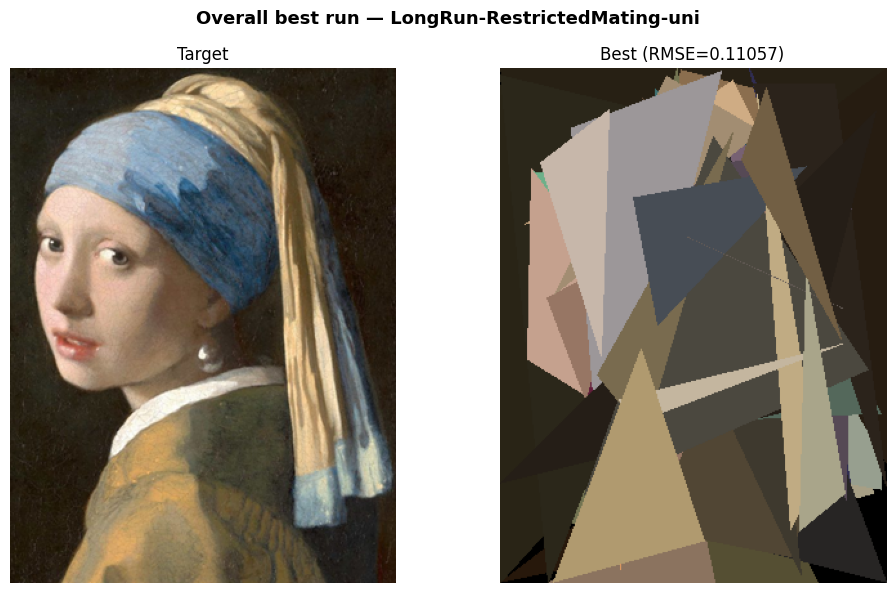

In [5]:
# Render the best individual found across all runs
from src.load_image import load_target_image
from src import rendering

target_array = load_target_image(str(project_root / "images" / "girl_pearl_earing.png"))
H, W = target_array.shape[:2]

# Find the JSON file that produced the best result and load its individual
best_pipeline = best_row["pipeline"]
best_folder   = best_row["folder"]

best_individual = None
best_fitness_found = float("inf")

for json_path in sorted((results_root / best_folder).glob("*.json")):
    try:
        d = json.loads(json_path.read_text())
    except Exception:
        continue
    # Match by pipeline name and fitness value
    res = d.get("results", {})
    fitness = res.get("best_fitness") or res.get("final_best_fitness")
    if (d.get("pipeline") == best_pipeline
            and fitness is not None
            and abs(float(fitness) - best_row["best_fitness"]) < 1e-9
            and "best_individual" in d):
        from src.ga.parallel import _individual_from_json
        best_individual = _individual_from_json(d["best_individual"])
        best_fitness_found = float(fitness)
        break

if best_individual is not None:
    rendered = rendering.render_individual(best_individual, image_width=W, image_height=H)
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes[0].imshow(target_array);  axes[0].set_title("Target");  axes[0].axis("off")
    axes[1].imshow(rendered);      axes[1].set_title(f"Best (RMSE={best_fitness_found:.5f})"); axes[1].axis("off")
    plt.suptitle(f"Overall best run — {best_pipeline}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Best run comes from a search schema that does not store the individual — cannot render.")

## 3 · Parameter analysis

Each section below groups all runs that varied one parameter, computes mean and standard deviation of RMSE, and plots the distribution.

> Note: runs with very few trials (e.g. n=1 long-run experiments) have no meaningful std — these are highlighted in the summary tables.

### 3.1 Population size

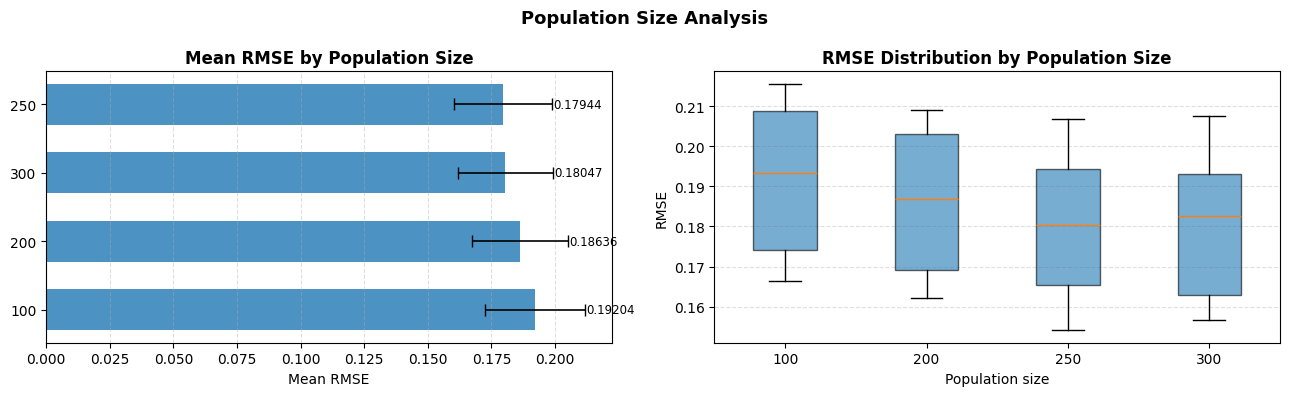

,★,Population size,n,mean,std,min,max
2,★,250,10,0.179443,0.019202,0.154089,0.206892
3,,300,10,0.180468,0.018723,0.156587,0.207591
1,,200,10,0.186358,0.018876,0.162049,0.209005
0,,100,10,0.192044,0.019603,0.166365,0.215589


In [6]:
pop_data = df[df["folder"] == "population_size"].copy()
pop_agg = param_summary(pop_data, "population_size", "Population size")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_with_error(
    axes[0],
    labels=[str(v) for v in pop_agg["Population size"]],
    means=pop_agg["mean"].values,
    stds=pop_agg["std"].values,
    title="Mean RMSE by Population Size",
    color=COLORS[0],
)

pop_sizes = sorted(pop_data["population_size"].unique())
data_by_pop = [pop_data[pop_data["population_size"] == p]["best_fitness"].values for p in pop_sizes]
axes[1].boxplot(data_by_pop, labels=[str(p) for p in pop_sizes], patch_artist=True,
                boxprops=dict(facecolor=COLORS[0], alpha=0.6))
axes[1].set_xlabel("Population size")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution by Population Size", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Population Size Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(pop_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

### 3.2 Elitism

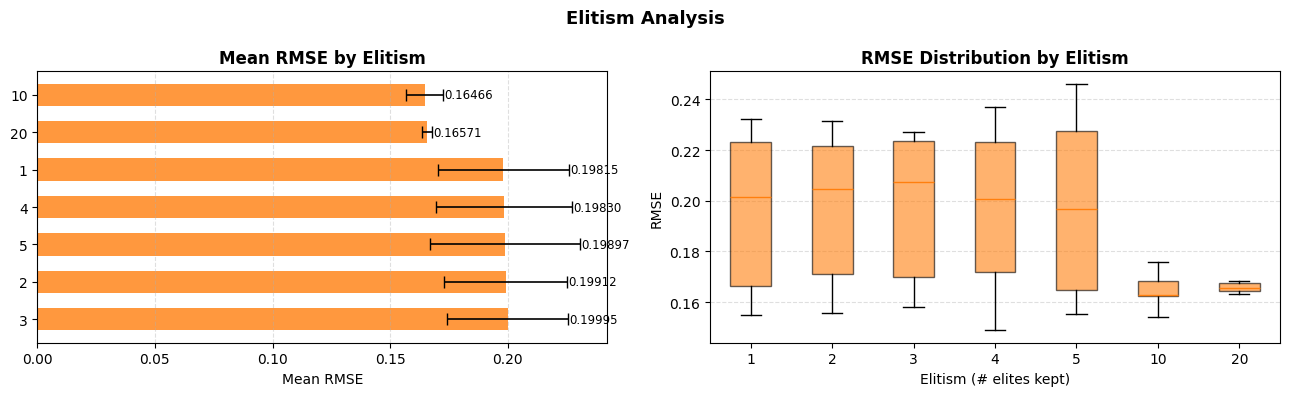

,★,Elitism,n,mean,std,min,max
5,★,10,5,0.164664,0.008005,0.154187,0.175798
6,,20,5,0.165707,0.002115,0.163298,0.168332
0,,1,16,0.198151,0.027746,0.155019,0.232240
3,,4,16,0.198296,0.028963,0.148808,0.236844
4,,5,16,0.198969,0.031836,0.155345,0.246217
1,,2,16,0.199115,0.026236,0.155606,0.231610
2,,3,16,0.199949,0.025873,0.157969,0.227138


In [7]:
elit_data = df[df["folder"] == "elitism"].copy()
elit_agg = param_summary(elit_data, "elitism", "Elitism")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_with_error(
    axes[0],
    labels=[str(v) for v in elit_agg["Elitism"]],
    means=elit_agg["mean"].values,
    stds=elit_agg["std"].values,
    title="Mean RMSE by Elitism",
    color=COLORS[1],
)

elit_values = sorted(elit_data["elitism"].unique())
data_by_elit = [elit_data[elit_data["elitism"] == e]["best_fitness"].values for e in elit_values]
axes[1].boxplot(data_by_elit, labels=[str(e) for e in elit_values], patch_artist=True,
                boxprops=dict(facecolor=COLORS[1], alpha=0.6))
axes[1].set_xlabel("Elitism (# elites kept)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution by Elitism", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Elitism Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(elit_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

### 3.3 Crossover operator

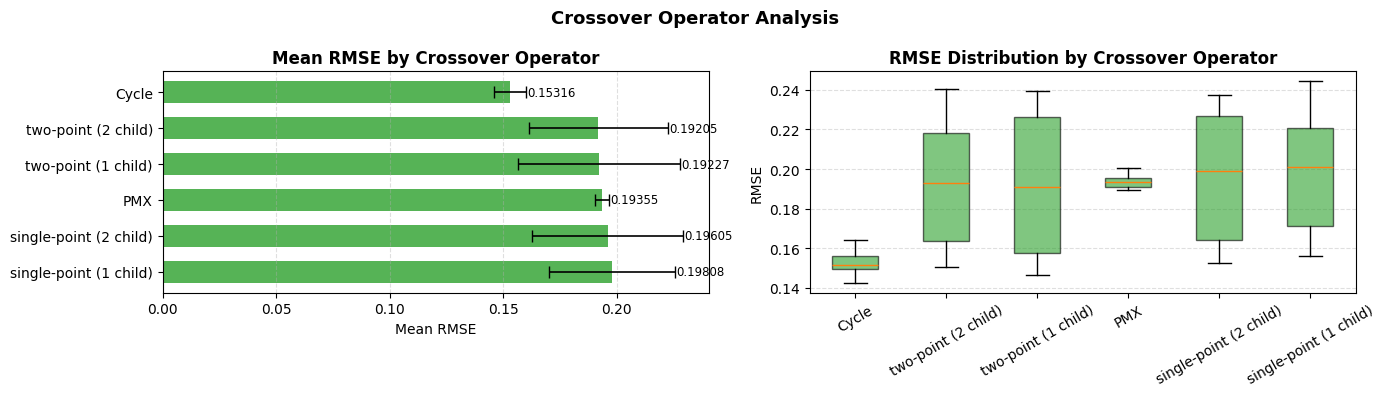

,★,Crossover,n,mean,std,min,max
0,★,Cycle,10,0.153162,0.007079,0.142682,0.164404
5,,two-point (2 child),20,0.192050,0.030635,0.150680,0.240524
4,,two-point (1 child),20,0.192266,0.035655,0.146756,0.239171
1,,PMX,10,0.193553,0.003261,0.189467,0.200329
3,,single-point (2 child),20,0.196046,0.033072,0.152798,0.237179
2,,single-point (1 child),30,0.198079,0.027744,0.156063,0.244261


In [8]:
xo_data = df[df["folder"] == "crossover_grid"].copy()

XO_LABELS = {
    "single_point_crossover":              "single-point (1 child)",
    "single_point_crossover_two_children": "single-point (2 child)",
    "two_point_crossover":                 "two-point (1 child)",
    "two_point_crossover_two_children":    "two-point (2 child)",
    "pmx_crossover":                       "PMX",
    "cycle_crossover":                     "Cycle",
    # grid_search.py stores shorter names
    "single_point_one_child":    "single-point (1 child)",
    "single_point_two_children": "single-point (2 child)",
    "two_point_one_child":       "two-point (1 child)",
    "two_point_two_children":    "two-point (2 child)",
    "pmx":                       "PMX",
    "cycle":                     "Cycle",
}
xo_data["xo_label"] = xo_data["crossover_function"].map(XO_LABELS).fillna(xo_data["crossover_function"])
xo_agg = param_summary(xo_data, "xo_label", "Crossover")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bar_with_error(
    axes[0],
    labels=xo_agg["Crossover"].tolist(),
    means=xo_agg["mean"].values,
    stds=xo_agg["std"].values,
    title="Mean RMSE by Crossover Operator",
    color=COLORS[2],
)

xo_ops = xo_agg["Crossover"].tolist()
data_by_xo = [xo_data[xo_data["xo_label"] == op]["best_fitness"].values for op in xo_ops]
axes[1].boxplot(data_by_xo, labels=xo_ops, patch_artist=True,
                boxprops=dict(facecolor=COLORS[2], alpha=0.6))
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution by Crossover Operator", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Crossover Operator Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(xo_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

### 3.4 Mutation rate

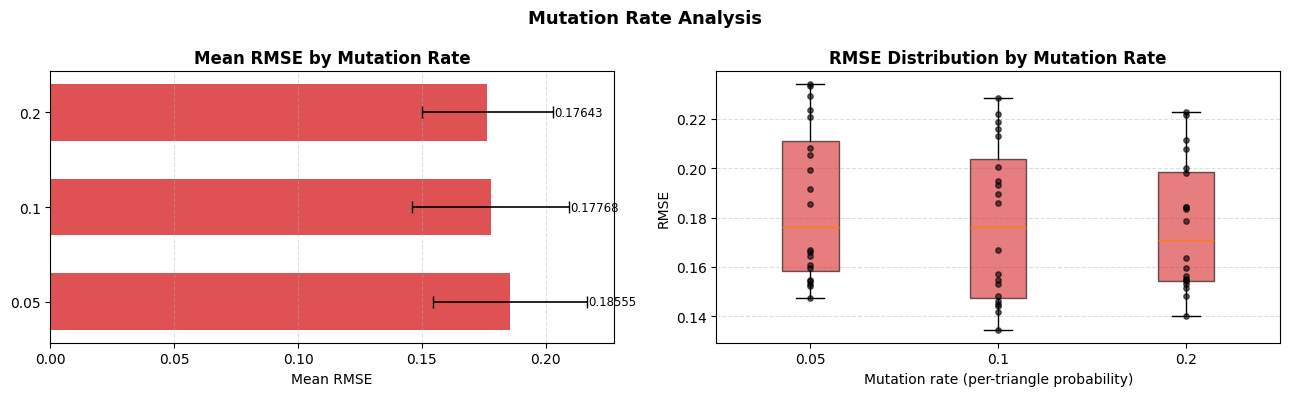

,★,Mutation rate,n,mean,std,min,max
2,★,0.20,20,0.176433,0.026283,0.140039,0.222777
1,,0.10,20,0.177684,0.031703,0.134299,0.228509
0,,0.05,20,0.185547,0.031127,0.147512,0.234321


In [9]:
mut_data = df[df["folder"] == "mutation_rate"].copy()
mut_agg = param_summary(mut_data, "mutation_rate", "Mutation rate")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_with_error(
    axes[0],
    labels=[str(v) for v in mut_agg["Mutation rate"]],
    means=mut_agg["mean"].values,
    stds=mut_agg["std"].values,
    title="Mean RMSE by Mutation Rate",
    color=COLORS[3],
)

mut_rates = sorted(mut_data["mutation_rate"].unique())
data_by_mut = [mut_data[mut_data["mutation_rate"] == r]["best_fitness"].values for r in mut_rates]
axes[1].boxplot(data_by_mut, labels=[str(r) for r in mut_rates], patch_artist=True,
                boxprops=dict(facecolor=COLORS[3], alpha=0.6))
axes[1].set_xlabel("Mutation rate (per-triangle probability)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution by Mutation Rate", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for i, r in enumerate(mut_rates):
    vals = mut_data[mut_data["mutation_rate"] == r]["best_fitness"].values
    axes[1].scatter(np.full_like(vals, i + 1), vals, color="k", s=15, zorder=5, alpha=0.6)

plt.suptitle("Mutation Rate Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(mut_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

### 3.5 Selection type

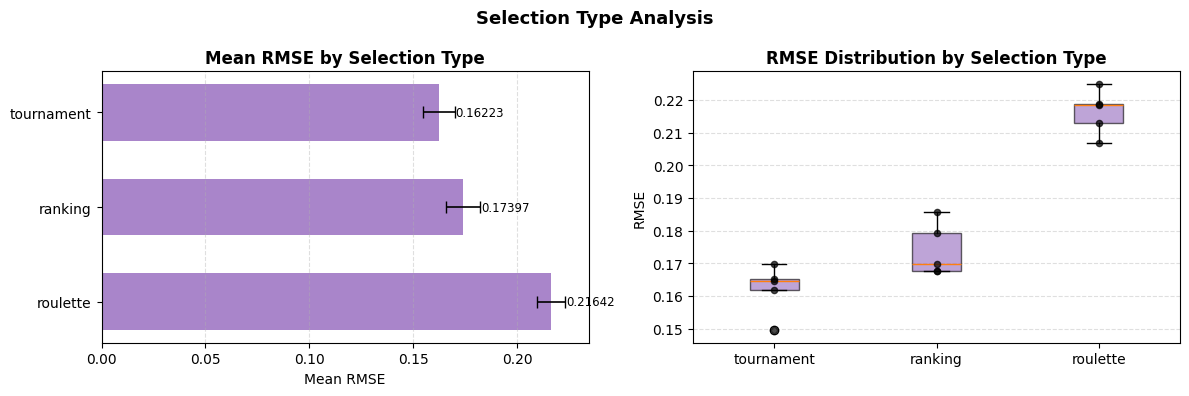

,★,Selection type,n,mean,std,min,max
2,★,tournament,5,0.162234,0.007697,0.149476,0.169934
0,,ranking,5,0.173966,0.008170,0.167573,0.185710
1,,roulette,5,0.216419,0.006802,0.206885,0.224952


In [10]:
sel_data = df[df["folder"] == "selection_type"].copy()
sel_agg = param_summary(sel_data, "selection_type", "Selection type")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_with_error(
    axes[0],
    labels=sel_agg["Selection type"].tolist(),
    means=sel_agg["mean"].values,
    stds=sel_agg["std"].values,
    title="Mean RMSE by Selection Type",
    color=COLORS[4],
)

sel_types = sel_agg["Selection type"].tolist()
data_by_sel = [sel_data[sel_data["selection_type"] == s]["best_fitness"].values for s in sel_types]
axes[1].boxplot(data_by_sel, labels=sel_types, patch_artist=True,
                boxprops=dict(facecolor=COLORS[4], alpha=0.6))
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution by Selection Type", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for i, s in enumerate(sel_types):
    vals = sel_data[sel_data["selection_type"] == s]["best_fitness"].values
    axes[1].scatter(np.full_like(vals, i + 1), vals, color="k", s=20, zorder=5, alpha=0.7)

plt.suptitle("Selection Type Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(sel_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

## 4 · Diversity methods

### 4.1 Fitness sharing — effect of niche radius σ

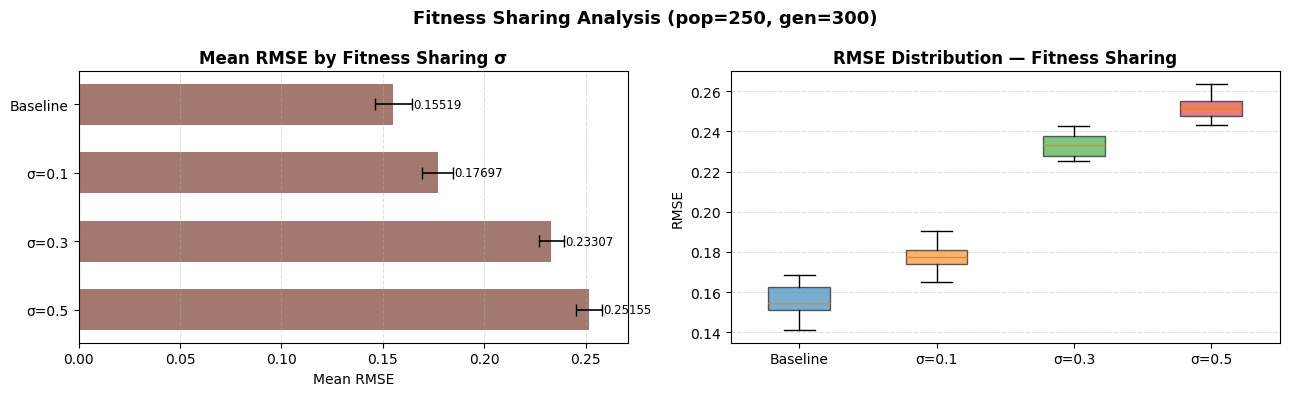

,★,Method,n,mean,std,min,max
0,★,Baseline,10,0.155187,0.009135,0.140892,0.168270
1,,σ=0.1,10,0.176967,0.007835,0.165070,0.190440
2,,σ=0.3,10,0.233074,0.006255,0.225481,0.242439
3,,σ=0.5,10,0.251552,0.006424,0.242951,0.263743


In [11]:
fs_data = df[df["folder"] == "fitness_sharing"].copy()

fs_data["method"] = fs_data["sigma_share"].apply(
    lambda s: "Baseline" if pd.isna(s) else f"σ={s}"
)
fs_data = fs_data[fs_data["population_size"] >= 250]

fs_agg = param_summary(fs_data, "method", "Method")
method_order = ["Baseline"] + sorted(
    [m for m in fs_agg["Method"] if m != "Baseline"],
    key=lambda s: float(s.split("=")[1])
)
fs_agg = fs_agg.set_index("Method").loc[method_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_fs = [COLORS[0]] + [COLORS[i + 1] for i in range(len(fs_agg) - 1)]
bar_with_error(
    axes[0],
    labels=fs_agg["Method"].tolist(),
    means=fs_agg["mean"].values,
    stds=fs_agg["std"].values,
    title="Mean RMSE by Fitness Sharing σ",
    color=COLORS[5],
)

data_by_method = [fs_data[fs_data["method"] == m]["best_fitness"].values for m in method_order]
bp = axes[1].boxplot(data_by_method, labels=method_order, patch_artist=True)
for patch, c in zip(bp["boxes"], colors_fs):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution — Fitness Sharing", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Fitness Sharing Analysis (pop=250, gen=300)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(fs_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

### 4.2 Restricted mating — effect of mating strategy

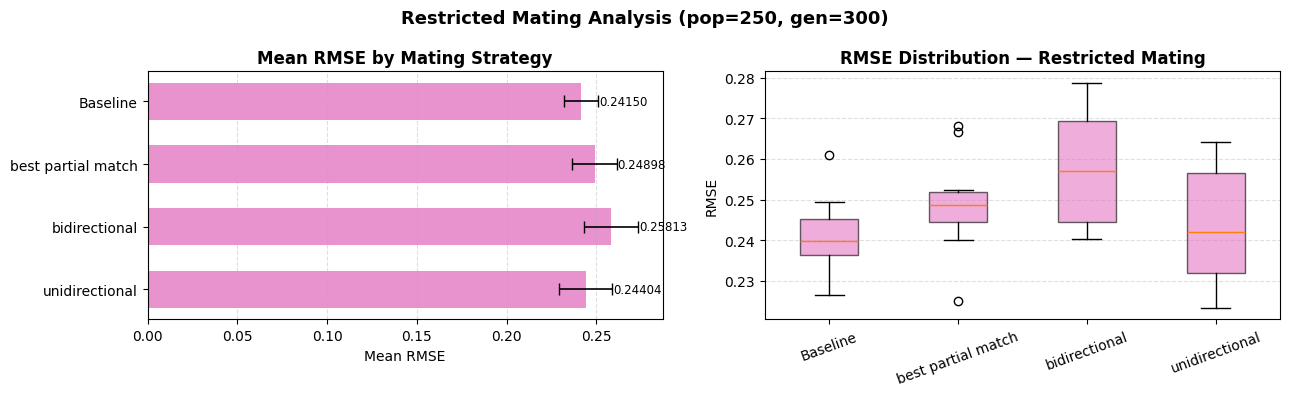

,★,Mating strategy,n,mean,std,min,max
0,★,Baseline,10,0.241504,0.009329,0.226473,0.260950
1,,best partial match,10,0.248984,0.012353,0.225117,0.268057
2,,bidirectional,10,0.258135,0.015130,0.240361,0.278781
3,,unidirectional,10,0.244037,0.014785,0.223300,0.264285


In [12]:
rm_data = df[df["folder"] == "restricted_mating"].copy()

rm_data["method"] = rm_data["mating_type"].apply(
    lambda m: "Baseline" if pd.isna(m) or m == "" else str(m).replace("_", " ")
)
rm_data = rm_data[rm_data["population_size"] >= 250]

rm_agg = param_summary(rm_data, "method", "Mating strategy")
method_order_rm = ["Baseline"] + sorted(
    [m for m in rm_agg["Mating strategy"] if m != "Baseline"]
)
rm_agg = rm_agg.set_index("Mating strategy").loc[method_order_rm].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_with_error(
    axes[0],
    labels=rm_agg["Mating strategy"].tolist(),
    means=rm_agg["mean"].values,
    stds=rm_agg["std"].values,
    title="Mean RMSE by Mating Strategy",
    color=COLORS[6],
)

data_by_rm = [rm_data[rm_data["method"] == m]["best_fitness"].values for m in method_order_rm]
bp = axes[1].boxplot(data_by_rm, labels=method_order_rm, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS[6]); patch.set_alpha(0.6)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Distribution — Restricted Mating", fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Restricted Mating Analysis (pop=250, gen=300)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

show_table(rm_agg, fmt={"mean": "{:.6f}", "std": "{:.6f}", "min": "{:.6f}", "max": "{:.6f}"},
           highlight_min="mean")

## 5 · Grid search & random search results

These runs exhaustively (grid) or randomly sampled combinations of crossover operator, selection type, and restricted mating strategy — all with pop=250, gen=500, elitism=5, fitness-sharing σ=0.3.

In [13]:
search_data = df[df["folder"].isin(["grid_search", "random_search"])].copy()
search_data["xo_label"] = search_data["crossover_function"].map(XO_LABELS).fillna(search_data["crossover_function"])

print(f"Total search runs: {len(search_data)}")
print(f"  Grid search  : {(search_data['folder']=='grid_search').sum()}")
print(f"  Random search: {(search_data['folder']=='random_search').sum()}")
print(f"\nRMSE range: {search_data['best_fitness'].min():.5f} – {search_data['best_fitness'].max():.5f}")

print("\nTop 10 search configurations:")
top_search = (
    search_data[["pipeline", "folder", "best_fitness", "xo_label", "selection_type", "mating_type"]]
    .nsmallest(10, "best_fitness")
    .reset_index(drop=True)
)
top_search.index += 1
show_table(top_search, fmt={"best_fitness": "{:.6f}"})

Total search runs: 40
  Grid search  : 29
  Random search: 11

RMSE range: 0.22739 – 0.31130

Top 10 search configurations:


,pipeline,folder,best_fitness,xo_label,selection_type,mating_type
1,search-pmx-tournament-unidirectional-mut0.1-xo0.9,random_search,0.227391,PMX,tournament,unidirectional
2,search-pmx-ranking-unidirectional-mut0.1-xo0.9,random_search,0.229579,PMX,ranking,unidirectional
3,search-two_point_one_child-tournament-unidirec...,grid_search,0.232305,two-point (1 child),tournament,unidirectional
4,search-two_point_one_child-ranking-unidirectio...,grid_search,0.236563,two-point (1 child),ranking,unidirectional
5,search-two_point_two_children-tournament-unidi...,grid_search,0.238826,two-point (2 child),tournament,unidirectional
6,search-two_point_two_children-tournament-unidi...,grid_search,0.238986,two-point (2 child),tournament,unidirectional
7,search-two_point_one_child-tournament-unidirec...,grid_search,0.240430,two-point (1 child),tournament,unidirectional
8,search-two_point_one_child-ranking-unidirectio...,grid_search,0.241956,two-point (1 child),ranking,unidirectional
9,search-two_point_one_child-tournament-unidirec...,grid_search,0.245801,two-point (1 child),tournament,unidirectional
10,search-two_point_one_child-ranking-unidirectio...,grid_search,0.245858,two-point (1 child),ranking,unidirectional


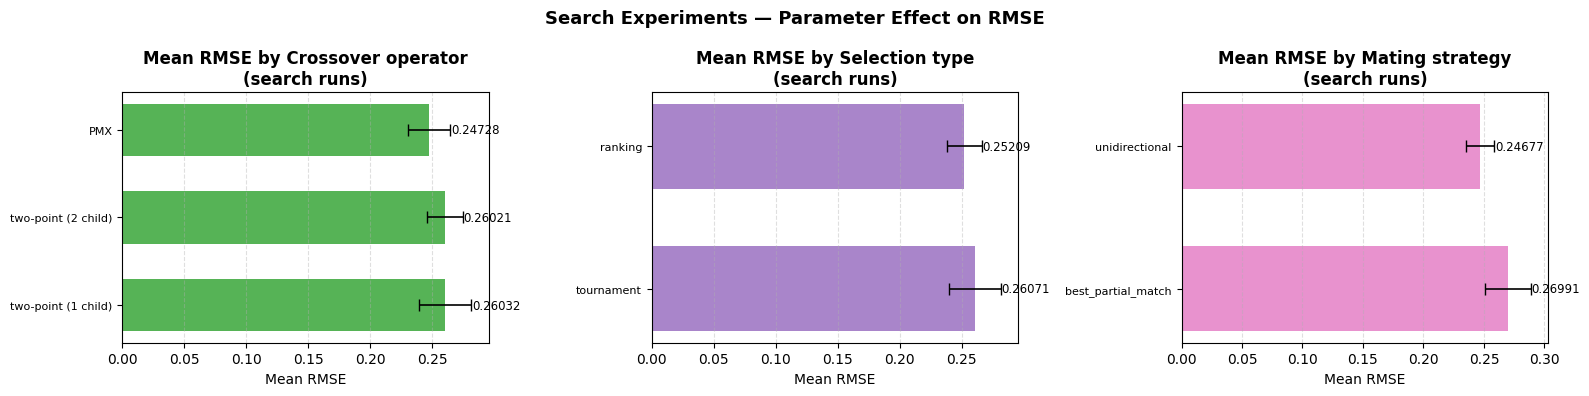

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label, color in [
    (axes[0], "xo_label",      "Crossover operator", COLORS[2]),
    (axes[1], "selection_type","Selection type",      COLORS[4]),
    (axes[2], "mating_type",   "Mating strategy",     COLORS[6]),
]:
    agg = (
        search_data.dropna(subset=[col])
        .groupby(col)["best_fitness"]
        .agg(mean="mean", std="std", n="count")
        .sort_values("mean")
        .reset_index()
    )
    agg["std"] = agg["std"].fillna(0)
    bar_with_error(ax, agg[col].tolist(), agg["mean"].values, agg["std"].values,
                   title=f"Mean RMSE by {label}\n(search runs)", color=color)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Search Experiments — Parameter Effect on RMSE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Long runs — does more time always help?

The `long_run` folder contains single trials at 1 000 and 3 000 generations (vs 300 for the main experiments) to see whether extended training keeps improving.

Long-run results (one trial each):


,★,method,generations,best_fitness,runtime_seconds
1,,Baseline,1000,0.125499,601
2,,Baseline,3000,0.117966,1829
3,,Baseline,3000,0.119285,1900
4,,FS-RM-uni,1000,0.204858,752
5,,FS-RM-uni,3000,0.198432,2264
6,,FS-RM-uni-σ0.5,3000,0.198082,2366
7,,FitnessSharing-σ0.5,3000,0.194445,2246
8,,FitnessSharing-σ03,1000,0.235370,718
9,,FitnessSharing-σ03,3000,0.218306,2166
10,,RestrictedMating-uni,1000,0.132937,633


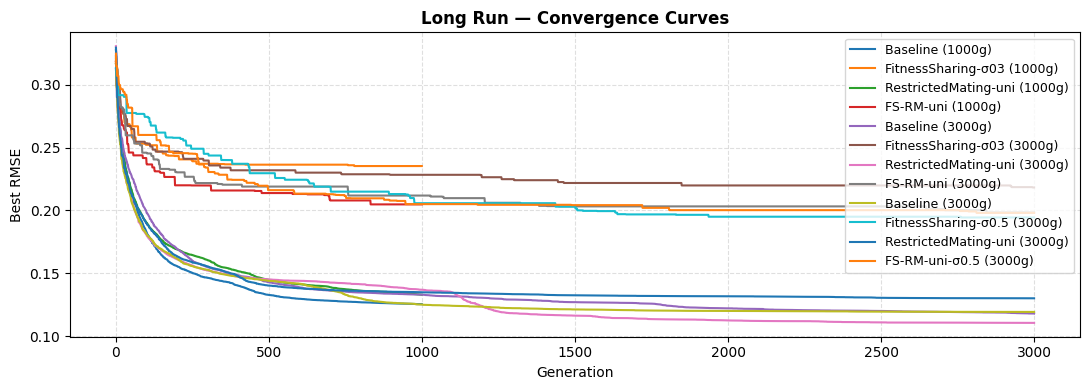

In [ ]:
lr_data = df[df["folder"] == "long_run"].copy()
lr_data["method"] = lr_data["pipeline"].str.replace("LongRun-", "", regex=False)

lr_table = (
    lr_data[["method", "generations", "best_fitness", "runtime_seconds"]]s
    .sort_values(["method", "generations"])
    .reset_index(drop=True)
)
lr_table.index += 1

print("Long-run results (one trial each):")
show_table(lr_table, fmt={"best_fitness": "{:.6f}", "runtime_seconds": "{:.0f}"},
           highlight_min="best_fitness")

# Convergence curves for runs that have history stored
lr_with_history = lr_data[lr_data["history"].notna()].copy()
if not lr_with_history.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    for i, (_, row) in enumerate(lr_with_history.iterrows()):
        ax.plot(row["history"], label=f"{row['method']} ({row['generations']}g)",
                color=COLORS[i % len(COLORS)], lw=1.5)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best RMSE")
    ax.set_title("Long Run — Convergence Curves", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("No convergence histories stored for long-run experiments.")

## 7 · Final summary — best config per experiment group

In [16]:
EXPERIMENT_GROUPS = {
    "Baseline":          df[df["folder"] == "baseline"],
    "Population size":   df[df["folder"] == "population_size"],
    "Elitism":           df[df["folder"] == "elitism"],
    "Crossover":         df[df["folder"] == "crossover_grid"],
    "Mutation rate":     df[df["folder"] == "mutation_rate"],
    "Selection type":    df[df["folder"] == "selection_type"],
    "Fitness sharing":   df[(df["folder"] == "fitness_sharing") & (df["population_size"] >= 250)],
    "Restricted mating": df[(df["folder"] == "restricted_mating") & (df["population_size"] >= 250)],
    "Grid search":       df[df["folder"] == "grid_search"],
    "Random search":     df[df["folder"] == "random_search"],
    "Long run":          df[df["folder"] == "long_run"],
}

summary_rows = []
for group_name, group_df in EXPERIMENT_GROUPS.items():
    if group_df.empty:
        continue
    best_idx = group_df["best_fitness"].idxmin()
    best = group_df.loc[best_idx]
    summary_rows.append({
        "Experiment":    group_name,
        "# runs":        len(group_df),
        "Mean RMSE":     group_df["best_fitness"].mean(),
        "Std RMSE":      group_df["best_fitness"].std(),
        "Best RMSE":     best["best_fitness"],
        "Best pipeline": best["pipeline"],
        "pop":           best["population_size"],
        "gen":           best["generations"],
        "elitism":       best["elitism"],
        "crossover":     XO_LABELS.get(str(best["crossover_function"]), best["crossover_function"]),
        "mut_rate":      best["mutation_rate"],
        "selection":     best["selection_type"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("Experiment")

show_table(
    summary_df.reset_index(),
    fmt={
        "Mean RMSE": "{:.6f}", "Std RMSE": "{:.6f}", "Best RMSE": "{:.6f}",
        "pop": "{:.0f}", "gen": "{:.0f}", "elitism": "{:.0f}", "mut_rate": "{:.2f}",
    },
    highlight_min="Best RMSE",
)

,★,Experiment,# runs,Mean RMSE,Std RMSE,Best RMSE,Best pipeline,pop,gen,elitism,crossover,mut_rate,selection
0,,Baseline,19,0.202570,0.029862,0.153905,Baseline-GA,300,300,1,single-point (1 child),0.10,tournament
1,,Population size,40,0.184578,0.019055,0.154089,PopSize-250,250,300,1,single-point (1 child),0.10,tournament
2,,Elitism,90,0.195150,0.028067,0.148808,Elitism-4,250,300,4,single-point (1 child),0.10,tournament
3,,Crossover,110,0.191062,0.030603,0.142682,Crossover-cycle-r0.9,250,300,5,Cycle,0.10,tournament
4,,Mutation rate,60,0.179888,0.029575,0.134299,MutRate-0.1,250,300,5,Cycle,0.10,tournament
5,,Selection type,15,0.184206,0.025094,0.149476,SelectionType-tournament,250,300,5,single-point (1 child),0.10,tournament
6,,Fitness sharing,40,0.204195,0.040581,0.140892,FitnessSharing-Baseline,250,300,5,Cycle,0.10,tournament
7,,Restricted mating,40,0.248165,0.014141,0.223300,RestrictedMating-unidirectional,250,300,5,two-point (2 child),0.10,tournament
8,,Grid search,29,0.257833,0.017375,0.232305,search-two_point_one_child-tournament-unidirec...,250,500,5,two-point (1 child),0.10,tournament
9,,Random search,11,0.259680,0.024864,0.227391,search-pmx-tournament-unidirectional-mut0.1-xo0.9,250,500,5,PMX,0.10,tournament


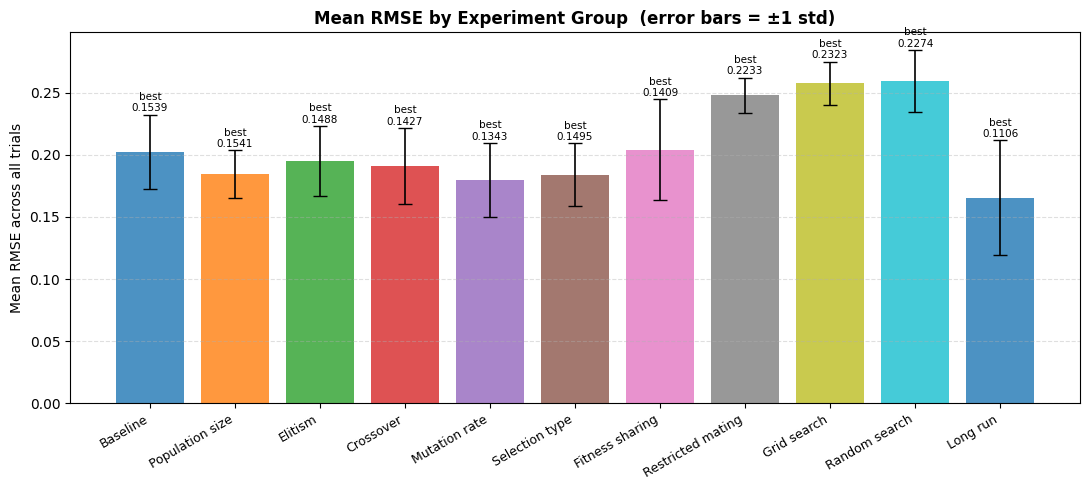

In [17]:
# Bar chart comparing mean RMSE across all experiment groups
fig, ax = plt.subplots(figsize=(11, 5))

groups  = summary_df.index.tolist()
means   = summary_df["Mean RMSE"].values
stds    = summary_df["Std RMSE"].fillna(0).values
best_vals = summary_df["Best RMSE"].values

x = np.arange(len(groups))
bars = ax.bar(x, means, yerr=stds, capsize=5, color=COLORS[:len(groups)],
              alpha=0.8, error_kw=dict(ecolor="black", lw=1.2))

# Annotate with best RMSE
for i, (m, b) in enumerate(zip(means, best_vals)):
    ax.text(i, m + stds[i] + 0.001, f"best\n{b:.4f}", ha="center", va="bottom",
            fontsize=7.5, color="black")

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean RMSE across all trials")
ax.set_title("Mean RMSE by Experiment Group  (error bars = ±1 std)", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()